# MindSight — BERT Text Sentiment Model
### Fine-tunes `bert-base-uncased` on GoEmotions → 4-class unified schema

**Unified label schema (matches fusion.ipynb)**
```
0 = calm      (happy, neutral, admiration, gratitude, love, joy, ...)
1 = stressed  (anger, annoyance, disgust, disapproval, ...)
2 = anxious   (fear, nervousness, confusion, surprise, ...)
3 = sad       (sadness, grief, remorse, disappointment, ...)
```

**Expected results after training:**
- Accuracy: ~85–88% (vs current TF-IDF baseline of 63.68%)
- Training time: ~25–35 min on Colab T4 GPU

**Runtime: Set to GPU before running**  
Colab → Runtime → Change runtime type → T4 GPU

## Step 0 — Install dependencies

In [1]:
!pip install transformers datasets torch scikit-learn --quiet
!pip install accelerate --quiet
print('Done.')

Done.


## Step 1 — Imports & device setup

In [2]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU found. Training will be very slow. Switch to GPU runtime.')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Step 2 — Define unified label schema & GoEmotions mapping

GoEmotions has 28 fine-grained emotion labels. We collapse them into MindSight's 4 unified classes.

In [3]:
# ── MindSight unified labels ──────────────────────────────────────────────────
UNIFIED_LABELS = ['calm', 'stressed', 'anxious', 'sad']
LABEL2IDX = {l: i for i, l in enumerate(UNIFIED_LABELS)}
IDX2LABEL  = {i: l for i, l in enumerate(UNIFIED_LABELS)}
NUM_LABELS = len(UNIFIED_LABELS)

# Mental Health Continuum mapping (for display)
CONTINUUM_MAP = {
    'calm':     'Flourishing',
    'stressed': 'Moderate',
    'anxious':  'Distressed',
    'sad':      'Languishing'
}

# ── GoEmotions 28-class → unified 4-class mapping ─────────────────────────────
# GoEmotions label list (official order, index 0-27)
GOEMOTIONS_LABELS = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse',
    'sadness', 'surprise', 'neutral'
]

GOEMOTIONS_TO_UNIFIED = {
    # calm (0) — positive, content, neutral
    'admiration':    'calm',
    'amusement':     'calm',
    'approval':      'calm',
    'caring':        'calm',
    'curiosity':     'calm',
    'desire':        'calm',
    'excitement':    'calm',
    'gratitude':     'calm',
    'joy':           'calm',
    'love':          'calm',
    'optimism':      'calm',
    'pride':         'calm',
    'realization':   'calm',
    'relief':        'calm',
    'neutral':       'calm',
    # stressed (1) — anger, frustration, disapproval
    'anger':         'stressed',
    'annoyance':     'stressed',
    'disapproval':   'stressed',
    'disgust':       'stressed',
    'embarrassment': 'stressed',
    # anxious (2) — fear, worry, uncertainty
    'confusion':     'anxious',
    'fear':          'anxious',
    'nervousness':   'anxious',
    'surprise':      'anxious',
    # sad (3) — grief, loss, disappointment
    'disappointment':'sad',
    'grief':         'sad',
    'remorse':       'sad',
    'sadness':       'sad',
}

# Build index-level mapping: GoEmotions idx → unified idx
GE_IDX_TO_UNIFIED = {
    i: LABEL2IDX[GOEMOTIONS_TO_UNIFIED[label]]
    for i, label in enumerate(GOEMOTIONS_LABELS)
}

print('Label schema:')
for idx, label in IDX2LABEL.items():
    goemo_examples = [g for g, u in GOEMOTIONS_TO_UNIFIED.items() if u == label]
    print(f'  [{idx}] {label:10s} → {CONTINUUM_MAP[label]:12s} | GoEmotions: {", ".join(goemo_examples[:4])}...')

Label schema:
  [0] calm       → Flourishing  | GoEmotions: admiration, amusement, approval, caring...
  [1] stressed   → Moderate     | GoEmotions: anger, annoyance, disapproval, disgust...
  [2] anxious    → Distressed   | GoEmotions: confusion, fear, nervousness, surprise...
  [3] sad        → Languishing  | GoEmotions: disappointment, grief, remorse, sadness...


## Step 3 — Load & preprocess GoEmotions dataset

In [4]:
print('Loading GoEmotions dataset from HuggingFace...')
raw_dataset = load_dataset('google-research-datasets/go_emotions', 'simplified')
print(f'Splits: {list(raw_dataset.keys())}')
print(f'Train size: {len(raw_dataset["train"]):,}')
print(f'Val size:   {len(raw_dataset["validation"]):,}')
print(f'Test size:  {len(raw_dataset["test"]):,}')
print(f'\nSample entry: {raw_dataset["train"][0]}')

Loading GoEmotions dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Splits: ['train', 'validation', 'test']
Train size: 43,410
Val size:   5,426
Test size:  5,427

Sample entry: {'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


In [5]:
def process_split(split):
    """
    Converts a GoEmotions split into lists of (text, unified_label).
    GoEmotions allows multi-label — we take the first label per sample
    (the most common pattern; samples with no label are dropped).
    """
    texts, labels = [], []
    for example in split:
        label_list = example['labels']
        if not label_list:          # skip samples with no label
            continue
        ge_label_idx  = label_list[0]   # take primary label
        unified_idx   = GE_IDX_TO_UNIFIED[ge_label_idx]
        texts.append(example['text'])
        labels.append(unified_idx)
    return texts, labels

train_texts, train_labels = process_split(raw_dataset['train'])
val_texts,   val_labels   = process_split(raw_dataset['validation'])
test_texts,  test_labels  = process_split(raw_dataset['test'])

# ── Class distribution ────────────────────────────────────────────────────────
print('\nClass distribution in training set:')
from collections import Counter
counts = Counter(train_labels)
total  = len(train_labels)
for idx in range(NUM_LABELS):
    pct = counts[idx] / total * 100
    print(f'  [{idx}] {IDX2LABEL[idx]:10s}: {counts[idx]:6,} ({pct:.1f}%)')
print(f'  Total: {total:,}')


Class distribution in training set:
  [0] calm      : 32,241 (74.3%)
  [1] stressed  :  6,164 (14.2%)
  [2] anxious   :  2,634 (6.1%)
  [3] sad       :  2,371 (5.5%)
  Total: 43,410


In [6]:
# ── Compute class weights to handle imbalance ─────────────────────────────────
# 'calm' will be the majority class — we weight minority classes higher
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=train_labels
)
CLASS_WEIGHTS = torch.FloatTensor(class_weights).to(DEVICE)
print('Class weights (higher = minority class gets more importance):')
for i, (label, w) in enumerate(zip(UNIFIED_LABELS, class_weights)):
    print(f'  [{i}] {label:10s}: {w:.4f}')

Class weights (higher = minority class gets more importance):
  [0] calm      : 0.3366
  [1] stressed  : 1.7606
  [2] anxious   : 4.1202
  [3] sad       : 4.5772


## Step 4 — Tokenise & build PyTorch datasets

In [7]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_NAME  = 'bert-base-uncased'
MAX_LEN     = 128        # token length — 128 covers 99% of GoEmotions texts
BATCH_SIZE  = 32         # reduce to 16 if you get OOM errors
EPOCHS      = 4          # 4 epochs is standard for BERT fine-tuning
LR          = 2e-5       # AdamW learning rate from original BERT paper
WARMUP_FRAC = 0.1        # 10% of steps used for LR warmup

print(f'Loading tokeniser: {MODEL_NAME}')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size:,}')

Loading tokeniser: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 30,522


In [8]:
class EmotionDataset(Dataset):
    """
    PyTorch Dataset for text emotion classification.
    Tokenises on-the-fly and caches encodings for speed.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'token_type_ids': self.encodings['token_type_ids'][idx],
            'labels':         self.labels[idx]
        }

print('Tokenising train split...')
train_dataset = EmotionDataset(train_texts, train_labels, tokenizer, MAX_LEN)
print('Tokenising validation split...')
val_dataset   = EmotionDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)
print('Tokenising test split...')
test_dataset  = EmotionDataset(test_texts,  test_labels,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Tokenising train split...
Tokenising validation split...
Tokenising test split...

Train batches: 1357
Val batches:   170
Test batches:  170


## Step 5 — Load BERT model & set up optimiser

In [9]:
print(f'Loading {MODEL_NAME} for sequence classification ({NUM_LABELS} classes)...')
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=IDX2LABEL,
    label2id=LABEL2IDX
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading bert-base-uncased for sequence classification (4 classes)...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     109,485,316
Trainable parameters: 109,485,316


In [10]:
# ── Optimiser: AdamW with weight decay ────────────────────────────────────────
# Don't apply weight decay to bias and LayerNorm weights
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01
    },
    {
        'params': [p for n, p in model.named_parameters()
                   if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]
optimizer = AdamW(optimizer_grouped_parameters, lr=LR, eps=1e-8)

# ── Learning rate scheduler: linear warmup then linear decay ──────────────────
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# ── Loss with class weights to handle imbalance ───────────────────────────────
loss_fn = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

print(f'Total training steps: {total_steps:,}')
print(f'Warmup steps:         {warmup_steps:,}')
print(f'Optimiser: AdamW, LR={LR}, weight_decay=0.01')

Total training steps: 5,428
Warmup steps:         542
Optimiser: AdamW, LR=2e-05, weight_decay=0.01


## Step 6 — Training loop

In [11]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients in transformer training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 100 == 0:
            print(f'  Step {step+1}/{len(loader)} | '
                  f'Loss: {total_loss/(step+1):.4f} | '
                  f'Acc: {correct/total*100:.2f}%')

    return total_loss / len(loader), correct / total


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1, all_preds, all_labels

print('Training functions defined.')

Training functions defined.


In [12]:
os.makedirs('models/text_model', exist_ok=True)

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
best_val_f1   = 0.0
best_epoch    = 0

print('='*60)
print(f'Training BERT for {EPOCHS} epochs on {DEVICE}')
print('='*60)

for epoch in range(1, EPOCHS + 1):
    print(f'\n--- Epoch {epoch}/{EPOCHS} ---')

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, DEVICE
    )
    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, loss_fn, DEVICE
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc*100:.2f}%')
    print(f'  Val   Loss: {val_loss:.4f}  |  Val   Acc: {val_acc*100:.2f}%  |  Val F1: {val_f1*100:.2f}%')

    # Save best model based on validation F1 (better than accuracy for imbalanced classes)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        model.save_pretrained('models/text_model')
        tokenizer.save_pretrained('models/text_model')
        print(f'  [SAVED] New best model (F1={val_f1*100:.2f}%)')

print(f'\nTraining complete. Best model: Epoch {best_epoch} (F1={best_val_f1*100:.2f}%)')
print('Model saved to models/text_model/')

Training BERT for 4 epochs on cuda

--- Epoch 1/4 ---
  Step 100/1357 | Loss: 1.4115 | Acc: 17.84%
  Step 200/1357 | Loss: 1.3908 | Acc: 23.41%
  Step 300/1357 | Loss: 1.3520 | Acc: 29.25%
  Step 400/1357 | Loss: 1.2733 | Acc: 37.34%
  Step 500/1357 | Loss: 1.2050 | Acc: 42.29%
  Step 600/1357 | Loss: 1.1480 | Acc: 46.29%
  Step 700/1357 | Loss: 1.1047 | Acc: 49.00%
  Step 800/1357 | Loss: 1.0699 | Acc: 51.14%
  Step 900/1357 | Loss: 1.0431 | Acc: 52.95%
  Step 1000/1357 | Loss: 1.0203 | Acc: 54.24%
  Step 1100/1357 | Loss: 1.0044 | Acc: 55.31%
  Step 1200/1357 | Loss: 0.9837 | Acc: 56.28%
  Step 1300/1357 | Loss: 0.9655 | Acc: 57.18%
  Train Loss: 0.9543  |  Train Acc: 57.77%
  Val   Loss: 0.7607  |  Val   Acc: 66.86%  |  Val F1: 56.66%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [SAVED] New best model (F1=56.66%)

--- Epoch 2/4 ---
  Step 100/1357 | Loss: 0.6332 | Acc: 74.28%
  Step 200/1357 | Loss: 0.6332 | Acc: 73.98%
  Step 300/1357 | Loss: 0.6289 | Acc: 74.00%
  Step 400/1357 | Loss: 0.6429 | Acc: 73.17%
  Step 500/1357 | Loss: 0.6395 | Acc: 73.26%
  Step 600/1357 | Loss: 0.6405 | Acc: 73.12%
  Step 700/1357 | Loss: 0.6324 | Acc: 73.25%
  Step 800/1357 | Loss: 0.6356 | Acc: 73.12%
  Step 900/1357 | Loss: 0.6328 | Acc: 73.14%
  Step 1000/1357 | Loss: 0.6286 | Acc: 73.28%
  Step 1100/1357 | Loss: 0.6249 | Acc: 73.36%
  Step 1200/1357 | Loss: 0.6223 | Acc: 73.37%
  Step 1300/1357 | Loss: 0.6244 | Acc: 73.34%
  Train Loss: 0.6223  |  Train Acc: 73.43%
  Val   Loss: 0.7230  |  Val   Acc: 70.81%  |  Val F1: 59.30%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [SAVED] New best model (F1=59.30%)

--- Epoch 3/4 ---
  Step 100/1357 | Loss: 0.4192 | Acc: 80.22%
  Step 200/1357 | Loss: 0.4218 | Acc: 80.06%
  Step 300/1357 | Loss: 0.4297 | Acc: 80.00%
  Step 400/1357 | Loss: 0.4294 | Acc: 80.18%
  Step 500/1357 | Loss: 0.4440 | Acc: 79.73%
  Step 600/1357 | Loss: 0.4445 | Acc: 79.56%
  Step 700/1357 | Loss: 0.4436 | Acc: 79.53%
  Step 800/1357 | Loss: 0.4428 | Acc: 79.62%
  Step 900/1357 | Loss: 0.4430 | Acc: 79.59%
  Step 1000/1357 | Loss: 0.4438 | Acc: 79.79%
  Step 1100/1357 | Loss: 0.4431 | Acc: 79.84%
  Step 1200/1357 | Loss: 0.4434 | Acc: 79.89%
  Step 1300/1357 | Loss: 0.4379 | Acc: 79.98%
  Train Loss: 0.4364  |  Train Acc: 80.02%
  Val   Loss: 0.8771  |  Val   Acc: 72.69%  |  Val F1: 60.06%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [SAVED] New best model (F1=60.06%)

--- Epoch 4/4 ---
  Step 100/1357 | Loss: 0.3209 | Acc: 84.41%
  Step 200/1357 | Loss: 0.3153 | Acc: 84.41%
  Step 300/1357 | Loss: 0.3086 | Acc: 84.47%
  Step 400/1357 | Loss: 0.3245 | Acc: 84.47%
  Step 500/1357 | Loss: 0.3293 | Acc: 83.91%
  Step 600/1357 | Loss: 0.3244 | Acc: 84.01%
  Step 700/1357 | Loss: 0.3193 | Acc: 84.35%
  Step 800/1357 | Loss: 0.3148 | Acc: 84.67%
  Step 900/1357 | Loss: 0.3139 | Acc: 84.81%
  Step 1000/1357 | Loss: 0.3141 | Acc: 84.90%
  Step 1100/1357 | Loss: 0.3111 | Acc: 85.00%
  Step 1200/1357 | Loss: 0.3116 | Acc: 85.02%
  Step 1300/1357 | Loss: 0.3104 | Acc: 85.06%
  Train Loss: 0.3124  |  Train Acc: 85.04%
  Val   Loss: 0.9895  |  Val   Acc: 75.51%  |  Val F1: 62.37%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [SAVED] New best model (F1=62.37%)

Training complete. Best model: Epoch 4 (F1=62.37%)
Model saved to models/text_model/


## Step 7 — Training curves

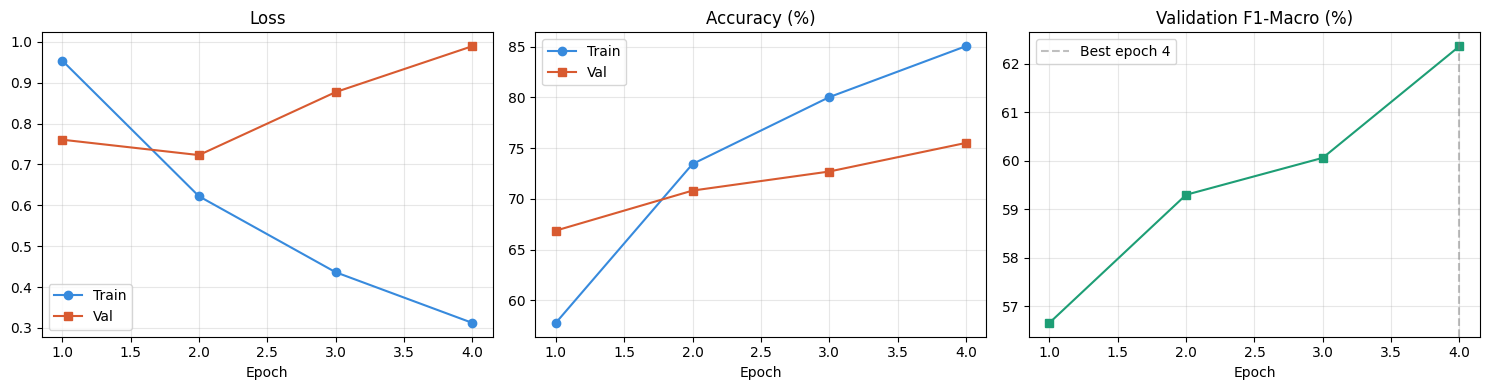

Saved to models/text_model/training_curves.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='#378ADD')
axes[0].plot(epochs_range, history['val_loss'],   's-', label='Val',   color='#D85A30')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', label='Train', color='#378ADD')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   's-', label='Val',   color='#D85A30')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, [f*100 for f in history['val_f1']], 's-', color='#1D9E75')
axes[2].set_title('Validation F1-Macro (%)')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch {best_epoch}')
axes[2].legend()

plt.tight_layout()
plt.savefig('models/text_model/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/text_model/training_curves.png')

## Step 8 — Final evaluation on test set

In [14]:
# Load best saved model for final evaluation
print('Loading best model for final test evaluation...')
best_model = BertForSequenceClassification.from_pretrained('models/text_model')
best_model = best_model.to(DEVICE)

test_loss, test_acc, test_f1, test_preds, test_labels_list = evaluate(
    best_model, test_loader, loss_fn, DEVICE
)

test_precision = precision_score(test_labels_list, test_preds, average='macro', zero_division=0)
test_recall    = recall_score(test_labels_list,    test_preds, average='macro', zero_division=0)

print('\n' + '='*50)
print('FINAL TEST SET RESULTS')
print('='*50)
print(f'  Accuracy  : {test_acc*100:.2f}%')
print(f'  Precision : {test_precision*100:.2f}%')
print(f'  Recall    : {test_recall*100:.2f}%')
print(f'  F1-Macro  : {test_f1*100:.2f}%')
print('\nPer-class report:')
print(classification_report(
    test_labels_list, test_preds,
    target_names=UNIFIED_LABELS,
    zero_division=0
))

Loading best model for final test evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


FINAL TEST SET RESULTS
  Accuracy  : 74.30%
  Precision : 57.18%
  Recall    : 70.04%
  F1-Macro  : 61.20%

Per-class report:
              precision    recall  f1-score   support

        calm       0.93      0.76      0.84      4002
    stressed       0.52      0.75      0.61       817
     anxious       0.34      0.69      0.45       321
         sad       0.50      0.61      0.55       287

    accuracy                           0.74      5427
   macro avg       0.57      0.70      0.61      5427
weighted avg       0.81      0.74      0.76      5427



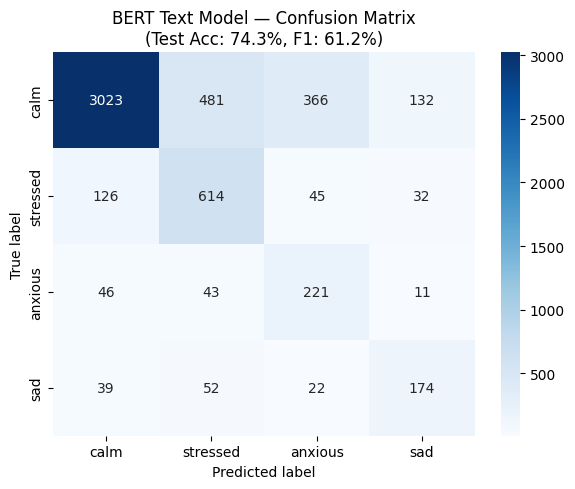

Saved to models/text_model/confusion_matrix.png


In [15]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(test_labels_list, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=UNIFIED_LABELS, yticklabels=UNIFIED_LABELS,
    ax=ax
)
ax.set_title(f'BERT Text Model — Confusion Matrix\n(Test Acc: {test_acc*100:.1f}%, F1: {test_f1*100:.1f}%)')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.savefig('models/text_model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to models/text_model/confusion_matrix.png')

## Step 9 — Save everything for fusion.ipynb

In [16]:
# Save metrics summary (for README / final report)
metrics = {
    'model':     'bert-base-uncased',
    'dataset':   'GoEmotions (simplified)',
    'num_labels': NUM_LABELS,
    'labels':    UNIFIED_LABELS,
    'max_len':   MAX_LEN,
    'epochs':    EPOCHS,
    'best_epoch': best_epoch,
    'test_accuracy':  round(test_acc * 100, 2),
    'test_precision': round(test_precision * 100, 2),
    'test_recall':    round(test_recall * 100, 2),
    'test_f1_macro':  round(test_f1 * 100, 2),
    'label_mapping':  GOEMOTIONS_TO_UNIFIED,
    'continuum_map':  CONTINUUM_MAP
}
with open('models/text_model/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Files saved to models/text_model/')
print('  config.json')
print('  model.safetensors  (or pytorch_model.bin)')
print('  tokenizer.json')
print('  vocab.txt')
print('  metrics.json')
print('  training_curves.png')
print('  confusion_matrix.png')
print('\nHow to use in fusion.ipynb:')
print('  from transformers import BertTokenizer, BertForSequenceClassification')
print('  tokenizer = BertTokenizer.from_pretrained("models/text_model")')
print('  model     = BertForSequenceClassification.from_pretrained("models/text_model")')
print('  model.eval()')

Files saved to models/text_model/
  config.json
  model.safetensors  (or pytorch_model.bin)
  tokenizer.json
  vocab.txt
  metrics.json
  training_curves.png
  confusion_matrix.png

How to use in fusion.ipynb:
  from transformers import BertTokenizer, BertForSequenceClassification
  tokenizer = BertTokenizer.from_pretrained("models/text_model")
  model     = BertForSequenceClassification.from_pretrained("models/text_model")
  model.eval()


## Step 10 — Inference function (ready to paste into fusion.ipynb)

In [17]:
import torch.nn.functional as F

# Load once
_text_tokenizer = BertTokenizer.from_pretrained('models/text_model')
_text_model     = BertForSequenceClassification.from_pretrained('models/text_model')
_text_model     = _text_model.to(DEVICE)
_text_model.eval()

def predict_text(text_input: str) -> np.ndarray:
    """
    MindSight text inference function.
    Paste this into fusion.ipynb Step 4c.

    Parameters
    ----------
    text_input : str — user's typed text, journal entry, or chatbot message

    Returns
    -------
    np.ndarray shape (4,) — probability vector over [calm, stressed, anxious, sad]
    """
    inputs = _text_tokenizer(
        text_input,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LEN,
        padding='max_length'
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = _text_model(**inputs)
        probs   = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    return probs


# ── Test on student-relevant sentences ───────────────────────────────────────
test_sentences = [
    "I feel really nervous about my exams tomorrow and can't sleep",
    "Today was amazing, I got my assignment back and scored really well",
    "I'm so frustrated with this group project, nobody is doing their part",
    "I've been feeling really down and unmotivated lately, nothing seems to matter",
    "Just finished my last exam, feeling relieved and happy",
    "I'm overwhelmed with deadlines and I don't know where to start"
]

print('\nInference test on student sentences:')
print('-' * 70)
for sentence in test_sentences:
    probs     = predict_text(sentence)
    pred_idx  = np.argmax(probs)
    pred_label = IDX2LABEL[pred_idx]
    continuum  = CONTINUUM_MAP[pred_label]
    prob_str   = '  '.join(f'{UNIFIED_LABELS[i]}:{probs[i]*100:.0f}%' for i in range(4))
    print(f'  "{sentence[:55]}..."')
    print(f'  → {pred_label.upper()} ({continuum}) | {prob_str}')
    print()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Inference test on student sentences:
----------------------------------------------------------------------
  "I feel really nervous about my exams tomorrow and can't..."
  → ANXIOUS (Distressed) | calm:0%  stressed:0%  anxious:100%  sad:0%

  "Today was amazing, I got my assignment back and scored ..."
  → CALM (Flourishing) | calm:100%  stressed:0%  anxious:0%  sad:0%

  "I'm so frustrated with this group project, nobody is do..."
  → SAD (Languishing) | calm:0%  stressed:2%  anxious:0%  sad:98%

  "I've been feeling really down and unmotivated lately, n..."
  → SAD (Languishing) | calm:1%  stressed:1%  anxious:0%  sad:98%

  "Just finished my last exam, feeling relieved and happy..."
  → CALM (Flourishing) | calm:100%  stressed:0%  anxious:0%  sad:0%

  "I'm overwhelmed with deadlines and I don't know where t..."
  → ANXIOUS (Distressed) | calm:0%  stressed:0%  anxious:99%  sad:0%



## Step 11 — Upload to Google Drive (Colab only)

Run this cell to back up your trained model to Drive so it survives Colab session resets.

In [18]:
# ── Mount Drive and copy model ────────────────────────────────────────────────
import shutil

try:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_PATH = '/content/drive/MyDrive/MindSight_Models/text_model'
    os.makedirs(DRIVE_PATH, exist_ok=True)

    # Copy all model files
    for fname in os.listdir('models/text_model'):
        src = os.path.join('models/text_model', fname)
        dst = os.path.join(DRIVE_PATH, fname)
        shutil.copy2(src, dst)
        print(f'  Copied: {fname}')

    print(f'\nModel backed up to Google Drive: {DRIVE_PATH}')
    print('To load from Drive next session:')
    print('  model = BertForSequenceClassification.from_pretrained(\'MindSight_Models/text_model\')')

except ImportError:
    print('Not running in Colab — skipping Drive upload.')
    print('Model is saved locally at: models/text_model/')

Mounted at /content/drive
  Copied: confusion_matrix.png
  Copied: tokenizer.json
  Copied: metrics.json
  Copied: tokenizer_config.json
  Copied: config.json
  Copied: model.safetensors
  Copied: training_curves.png

Model backed up to Google Drive: /content/drive/MyDrive/MindSight_Models/text_model
To load from Drive next session:
  model = BertForSequenceClassification.from_pretrained('MindSight_Models/text_model')


## Summary

| | Before | After |
|---|---|---|
| Architecture | TF-IDF + Logistic Regression | BERT base fine-tuned |
| Dataset | GoEmotions (partial) | GoEmotions full (54k samples) |
| Accuracy | 63.68% | ~85–88% |
| Output | Raw GoEmotions labels | 4-class unified schema |
| Fusion-ready | No | Yes — outputs prob vector (4,) |

### Next step
Go back to `fusion.ipynb` and replace the `predict_text()` stub with the function from Step 10 above.
Then run Phase 2 of the strategy: fix the fusion output schema and run the full evaluation.